In [3]:
import duckdb
import talib
from dotenv import load_dotenv
import os
import s3fs
import polars as pl
import boto3
load_dotenv()

pl.Config.set_fmt_str_lengths(50)

polars.config.Config

In [6]:

s3 = s3fs.S3FileSystem(
    key=os.getenv("S3_ACCESS_KEY"),
    secret=os.getenv("S3_SECRET_KEY"),
    token=os.getenv("AWS_SESSION_TOKEN"),  # optional but important if using temp creds
    client_kwargs={
        "region_name": "ca-central-1"
    }
)



In [7]:
# s3 setup using boto3
s3_client = boto3.client(
    's3',
    aws_access_key_id=os.getenv("S3_ACCESS_KEY"),
    aws_secret_access_key=os.getenv("S3_SECRET_KEY"),
    aws_session_token=os.getenv("AWS_SESSION_TOKEN"),  # optional but important if using temp creds
    region_name='ca-central-1'
)

#### S&P 500 Constituent List

In [8]:
# scan s3 bucket using duckdb

con = duckdb.connect()

bucket = os.getenv("S3_BUCKET")

snp500 = con.execute(f"""
SELECT *
FROM read_csv_auto('s3://{bucket}/post-earnings-forecast/**/*.csv')

""").df()
snp500

,#,Company,Symbol,Weight,Price,Chg,% Chg
0,1,NVIDIA Corp,NVDA,7.69%,215.33,-4.18,-1.90%
1,2,Apple Inc,AAPL,6.69%,308.82,3.83,1.26%
2,3,Microsoft Corp,MSFT,4.58%,418.57,-0.52,-0.12%
3,4,Amazon.com Inc,AMZN,4.22%,266.32,-2.14,-0.80%
4,5,Alphabet Inc,GOOGL,3.53%,382.97,-4.69,-1.21%
...,...,...,...,...,...,...,...
498,499,Pool Corp,POOL,0.01%,184.64,2.95,1.62%
499,500,Conagra Brands Inc,CAG,0.01%,13.56,0.18,1.35%
500,501,Campbell's Company/The,CPB,0.01%,20.58,0.53,2.64%
501,502,News Corp,NWS,0.01%,29.68,-0.40,-1.33%


#### Earnings Data

In [9]:
#  delta table for earnings
DELTA_EARNINGS = f"s3://{os.getenv('S3_BUCKET')}/post-earnings-forecast/earnings_delta/"


# storage options for delta lake
storage_options = {
    "AWS_ACCESS_KEY_ID": os.getenv("AWS_ACCESS_KEY_ID"),
    "AWS_SECRET_ACCESS_KEY": os.getenv("AWS_SECRET_ACCESS_KEY"),
    "AWS_REGION": "ca-central-1",
}


delta_earnings_df = ( 
    pl.scan_delta(DELTA_EARNINGS, storage_options=storage_options)
                  .filter(pl.col("symbol") == "AMZN")
                  .collect()
    )

# datatype casting for earnings dataframe
cast_cols = ["reportedEPS", "estimatedEPS", "surprise", "surprisePercentage"]
delta_earnings_df = delta_earnings_df.with_columns(
    [pl.col(c).cast(pl.Float64) for c in cast_cols]
)

delta_earnings_df.head()

fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,fiscal_month,fiscal_year,av_quarter,time_from
date,date,f64,f64,f64,f64,str,str,i8,i32,str,str
2018-09-30,2018-10-25,0.29,0.16,0.13,81.25,"""post-market""","""AMZN""",9,2018,"""2018Q3""","""20181025T0000"""
2017-06-30,2017-07-27,0.02,0.07,-0.05,-71.4286,"""post-market""","""AMZN""",6,2017,"""2017Q2""","""20170727T0000"""
2016-09-30,2016-10-27,0.03,0.04,-0.01,-25.0,"""post-market""","""AMZN""",9,2016,"""2016Q3""","""20161027T0000"""
2016-03-31,2016-04-28,0.05,0.03,0.02,66.6667,"""post-market""","""AMZN""",3,2016,"""2016Q1""","""20160428T0000"""
2016-12-31,2017-02-02,0.08,0.07,0.01,14.2857,"""post-market""","""AMZN""",12,2016,"""2016Q4""","""20170202T0000"""


#### Transcripts Data

In [10]:
DELTA_TRANSCRIPTS = f"s3://{os.getenv('S3_BUCKET')}/post-earnings-forecast/transcripts_delta/"
# polars options 

df_tx = pl.scan_delta(DELTA_TRANSCRIPTS, storage_options=storage_options).collect()

df_transcripts = df_tx.filter(pl.col('symbol') == 'AMZN')
df_transcripts.to_pandas().head()

,fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,fiscal_month,fiscal_year,av_quarter,time_from,transcript
0,2013-12-31,2014-01-30,0.03,0.03,0,0,post-market,AMZN,12,2013,2013Q4,20140130T0000,"[{'speaker': 'Cindy McCann', 'title': 'Vice Pr..."
1,2015-09-30,2015-10-22,0.01,-0.01,0.02,200,post-market,AMZN,9,2015,2015Q3,20151022T0000,"[{'speaker': 'Phil Hardin', 'title': 'Director..."
2,2017-09-30,2017-10-26,0.03,0.03,0,0,post-market,AMZN,9,2017,2017Q3,20171026T0000,"[{'speaker': 'Operator', 'title': 'Operator', ..."
3,2019-06-30,2019-07-25,0.26,0.28,-0.02,-7.1429,post-market,AMZN,6,2019,2019Q2,20190725T0000,"[{'speaker': 'Operator', 'title': 'Operator', ..."
4,2021-06-30,2021-07-29,0.76,0.62,0.14,22.5806,post-market,AMZN,6,2021,2021Q2,20210729T0000,"[{'speaker': 'Operator', 'title': 'Operator', ..."


#### OHLCV Data

In [11]:
DELTA_OHLVC = f"s3://{bucket}/post-earnings-forecast/ohlcv_delta/"
df_ohlvc = pl.read_delta(DELTA_OHLVC, storage_options=storage_options)
df_ohlvc = df_ohlvc.filter(pl.col('symbol') == 'AMZN')
df_ohlvc.head()

symbol,date,open,high,low,close,volume
str,date,f64,f64,f64,f64,i64
"""AMZN""",2000-08-25,1.95625,2.003125,1.928125,1.996875,54172000
"""AMZN""",1997-06-23,0.077083,0.077083,0.073958,0.075,20952000
"""AMZN""",1997-07-03,0.079948,0.095833,0.079688,0.095573,251544000
"""AMZN""",1997-07-15,0.106771,0.123958,0.106771,0.121875,185496000
"""AMZN""",1997-08-12,0.114063,0.115104,0.109896,0.109896,11424000


#### Schema Inspection

In [12]:
# Inspecting the dataframes
for name, df in [("EARNINGS", delta_earnings_df), 
                 ("TRANSCRIPTS", df_transcripts), 
                 ("OHLCV", df_ohlvc)]:
    print(f"\n{'='*50}")
    print(f"{name}  shape={df.shape}")
    print(f"{'='*50}")
    print(df.head(2))


EARNINGS  shape=(50, 12)
shape: (2, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ fiscalDat ┆ reportedD ┆ reportedE ┆ estimated ┆ … ┆ fiscal_mo ┆ fiscal_ye ┆ av_quarte ┆ time_fro │
│ eEnding   ┆ ate       ┆ PS        ┆ EPS       ┆   ┆ nth       ┆ ar        ┆ r         ┆ m        │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ date      ┆ date      ┆ f64       ┆ f64       ┆   ┆ i8        ┆ i32       ┆ str       ┆ str      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2018-09-3 ┆ 2018-10-2 ┆ 0.29      ┆ 0.16      ┆ … ┆ 9         ┆ 2018      ┆ 2018Q3    ┆ 20181025 │
│ 0         ┆ 5         ┆           ┆           ┆   ┆           ┆           ┆           ┆ T0000    │
│ 2017-06-3 ┆ 2017-07-2 ┆ 0.02      ┆ 0.07      ┆ … ┆ 6         ┆ 2017      ┆ 2017Q2    ┆ 20170727 │
│ 0         ┆ 7         ┆           ┆           ┆ 

#### Technical Indicator Engineering

| Indicator | Function | Parameters | Columns Produced |
|-----------|----------|------------|------------------|
| RSI | compute_rsi | period=14 | rsi |
| MACD | compute_macd | fast=12, slow=26, signal=9 | macd, macdsignal, macdhist |
| Bollinger Bands | compute_bollinger_bands | period=20, 2 std | bb_upper, bb_middle, bb_lower |
| ATR | compute_atr | period=14 | atr |
| OBV | compute_obv | - | obv |
| Derived | compute_derived | - | daily_return, intraday_range, gap, volume_change |

In [13]:
# rsi technical indicator calculation
def compute_rsi(ohlcv):
    results = []

    for symbol in ohlcv['symbol'].unique().sort().to_list():
        stock = ohlcv.filter(pl.col('symbol') == symbol).sort('date').to_pandas()
        stock['rsi'] = talib.RSI(stock['close'], timeperiod=14)
        results.append(pl.from_pandas(stock[['symbol', 'date', 'rsi']]))
    return pl.concat(results)


# macd technical indicator calculation
def compute_macd(ohlcv):
    results = []

    for symbol in ohlcv['symbol'].unique().sort().to_list():
        stock = ohlcv.filter(pl.col('symbol') == symbol).sort('date').to_pandas()
        macd, macdsignal, macdhist = talib.MACD(stock['close'], fastperiod=12, slowperiod=26, signalperiod=9)
        stock['macd'] = macd
        stock['macdsignal'] = macdsignal
        stock['macdhist'] = macdhist
        results.append(pl.from_pandas(stock[['symbol', 'date', 'macd', 'macdsignal', 'macdhist']]))
    return pl.concat(results)


# bollinger bands technical indicator calculation
def compute_bollinger_bands(ohlcv):
    results = []

    for symbol in ohlcv['symbol'].unique().sort().to_list():
        stock = ohlcv.filter(pl.col('symbol') == symbol).sort('date').to_pandas()
        upperband, middleband, lowerband = talib.BBANDS(stock['close'], timeperiod=20)
        stock['bb_upper'] = upperband
        stock['bb_middle'] = middleband
        stock['bb_lower'] = lowerband
        results.append(pl.from_pandas(stock[['symbol', 'date', 'bb_upper', 'bb_middle', 'bb_lower']]))
    return pl.concat(results)


# average true range technical indicator calculation
def compute_atr(ohlcv):
    results = []
    for symbol in ohlcv["symbol"].unique().sort().to_list():
        stock = ohlcv.filter(pl.col("symbol") == symbol).sort("date").to_pandas()
        stock["atr"] = talib.ATR(stock["high"].values, stock["low"].values, stock["close"].values, timeperiod=14)
        results.append(pl.from_pandas(stock[["symbol", "date", "atr"]]))
    return pl.concat(results)

# obv technical indicator calculation
def compute_obv(ohlcv):
    results = []
    for symbol in ohlcv["symbol"].unique().sort().to_list():
        stock = ohlcv.filter(pl.col("symbol") == symbol).sort("date").to_pandas()
        stock["obv"] = talib.OBV(stock["close"].values, stock["volume"].values.astype(float))
        results.append(pl.from_pandas(stock[["symbol", "date", "obv"]]))
    return pl.concat(results)

# derived features calculation
def compute_derived(ohlcv):
    results = []
    for symbol in ohlcv["symbol"].unique().sort().to_list():
        stock = ohlcv.filter(pl.col("symbol") == symbol).sort("date").to_pandas()
        stock["daily_return"] = stock["close"].pct_change()
        stock["intraday_range"] = (stock["high"] - stock["low"]) / stock["close"]
        stock["gap"] = (stock["open"] - stock["close"].shift(1)) / stock["close"].shift(1)
        stock["volume_change"] = stock["volume"].pct_change()
        results.append(pl.from_pandas(stock[["symbol", "date", "daily_return", "intraday_range", "gap", "volume_change"]]))
    return pl.concat(results)


### Compute & Combine All Technical Indicators

In [14]:
# Compute each separately
rsi_df   = compute_rsi(df_ohlvc)
macd_df  = compute_macd(df_ohlvc)
bb_df    = compute_bollinger_bands(df_ohlvc)
atr_df   = compute_atr(df_ohlvc)
obv_df   = compute_obv(df_ohlvc)
derived_df = compute_derived(df_ohlvc)

# Merge all features together
ta_combined = (
    rsi_df.join(macd_df, on=["symbol", "date"], how="left")
          .join(bb_df, on=["symbol", "date"], how="left")
          .join(atr_df, on=["symbol", "date"], how="left")
          .join(obv_df, on=["symbol", "date"], how="left")
          .join(derived_df, on=["symbol", "date"], how="left")
)

print(f"Combined TA features shape: {ta_combined.shape}")


Combined TA features shape: (7305, 15)


### Join Technical Indicators with OHLCV

In [15]:
# join technical indicators with OHLCV
ta_combined = ta_combined.with_columns(pl.col("date").cast(pl.Date))

ohlcv_with_ta = df_ohlvc.join(ta_combined, on=["symbol", "date"], how="left")
print(f"Enriched OHLCV shape: {ohlcv_with_ta.shape}")
print(f"Columns: {ohlcv_with_ta.columns}")

Enriched OHLCV shape: (7305, 20)
Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'rsi', 'macd', 'macdsignal', 'macdhist', 'bb_upper', 'bb_middle', 'bb_lower', 'atr', 'obv', 'daily_return', 'intraday_range', 'gap', 'volume_change']


In [16]:
ohlcv_with_ta.head()

symbol,date,open,high,low,close,volume,rsi,macd,macdsignal,macdhist,bb_upper,bb_middle,bb_lower,atr,obv,daily_return,intraday_range,gap,volume_change
str,date,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AMZN""",2000-08-25,1.95625,2.003125,1.928125,1.996875,54172000,59.27754,0.032955,-0.009865,0.04282,2.089903,1.743438,1.396972,0.138757,2.3551e10,0.014286,0.037559,-0.006349,-0.426022
"""AMZN""",1997-06-23,0.077083,0.077083,0.073958,0.075,20952000,34.747186,null,null,null,0.083182,0.077122,0.071063,0.004884,6.97632e8,-0.017064,0.041667,0.010236,-0.690755
"""AMZN""",1997-07-03,0.079948,0.095833,0.079688,0.095573,251544000,65.736768,0.001149,-0.000092,0.001241,0.087871,0.078398,0.068926,0.004905,1.0472e9,0.203281,0.168929,0.00656,2.239876
"""AMZN""",1997-07-15,0.106771,0.123958,0.106771,0.121875,185496000,66.723295,0.010625,0.006917,0.003709,0.128392,0.090456,0.05252,0.008234,1.7476e9,0.141462,0.141022,0.0,1.014334
"""AMZN""",1997-08-12,0.114063,0.115104,0.109896,0.109896,11424000,49.880359,0.003746,0.005519,-0.001774,0.123682,0.114089,0.104495,0.007021,1.6846e9,-0.055925,0.04739,-0.020128,-0.539206


#### EPS & Transcript Feature Engineering


In [17]:
# EPS feature engineering
def add_eps_features(earnings):
    earnings = earnings.sort(["symbol", "reportedDate"])

    earnings = earnings.with_columns([
        ((pl.col("reportedEPS") - pl.col("reportedEPS").shift(1).over("symbol"))
         / pl.col("reportedEPS").shift(1).over("symbol").abs())
        .alias("eps_growth"),

        (pl.col("surprise") - pl.col("surprise").shift(1).over("symbol"))
        .alias("surprise_trend"),

        (pl.col("surprise") > 0).cast(pl.Int8).alias("beat"),
    ])

    # consecutive beats streak
    earnings = earnings.sort(["symbol", "reportedDate"])
    streaks = []
    for symbol in earnings["symbol"].unique().sort().to_list():
        stock = earnings.filter(pl.col("symbol") == symbol).sort("reportedDate")
        count = 0
        for b in stock["beat"].to_list():
            count = count + 1 if b == 1 else 0
            streaks.append(count)

    earnings = earnings.with_columns(pl.Series("consecutive_beats", streaks))
    print(f"EPS features added: eps_growth, surprise_trend, beat, consecutive_beats")
    return earnings

delta_earnings_df = add_eps_features(delta_earnings_df)
print(delta_earnings_df.select(
    "symbol", "reportedDate", "reportedEPS", "surprise",
    "eps_growth", "surprise_trend", "beat", "consecutive_beats"
).head(10))

EPS features added: eps_growth, surprise_trend, beat, consecutive_beats
shape: (10, 8)
┌────────┬──────────────┬─────────────┬──────────┬────────────┬──────────────┬──────┬──────────────┐
│ symbol ┆ reportedDate ┆ reportedEPS ┆ surprise ┆ eps_growth ┆ surprise_tre ┆ beat ┆ consecutive_ │
│ ---    ┆ ---          ┆ ---         ┆ ---      ┆ ---        ┆ nd           ┆ ---  ┆ beats        │
│ str    ┆ date         ┆ f64         ┆ f64      ┆ f64        ┆ ---          ┆ i8   ┆ ---          │
│        ┆              ┆             ┆          ┆            ┆ f64          ┆      ┆ i64          │
╞════════╪══════════════╪═════════════╪══════════╪════════════╪══════════════╪══════╪══════════════╡
│ AMZN   ┆ 2014-01-30   ┆ 0.03        ┆ 0.0      ┆ null       ┆ null         ┆ 0    ┆ 0            │
│ AMZN   ┆ 2014-04-24   ┆ 0.01        ┆ 0.0      ┆ -0.666667  ┆ 0.0          ┆ 0    ┆ 0            │
│ AMZN   ┆ 2014-07-24   ┆ -0.01       ┆ 0.0      ┆ -2.0       ┆ 0.0          ┆ 0    ┆ 0            │
│ AM

#### Transcript features

In [18]:
# Transcript feature engineering
def add_transcript_features(transcripts):
    texts = []
    for row in transcripts.iter_rows(named=True):
        transcript = row["transcript"]
        if transcript is None:
            texts.append("")
            continue
        full_text = " ".join([
            item["text"] if isinstance(item, dict) and "text" in item
            else str(item)
            for item in transcript
        ])
        texts.append(full_text)

    transcripts = transcripts.with_columns(
        pl.Series("transcript_text", texts)
    )
    transcripts = transcripts.with_columns([
        pl.col("transcript_text").str.split(" ").list.len().alias("transcript_word_count"),
        pl.col("transcript_text").str.len_chars().alias("transcript_char_count"),
    ])
    print(f"Transcript features added")
    return transcripts

df_transcripts = add_transcript_features(df_transcripts)

Transcript features added


In [19]:
delta_earnings_df.head()

fiscalDateEnding,reportedDate,reportedEPS,estimatedEPS,surprise,surprisePercentage,reportTime,symbol,fiscal_month,fiscal_year,av_quarter,time_from,eps_growth,surprise_trend,beat,consecutive_beats
date,date,f64,f64,f64,f64,str,str,i8,i32,str,str,f64,f64,i8,i64
2013-12-31,2014-01-30,0.03,0.03,0.0,0.0,"""post-market""","""AMZN""",12,2013,"""2013Q4""","""20140130T0000""",null,null,0,0
2014-03-31,2014-04-24,0.01,0.01,0.0,0.0,"""post-market""","""AMZN""",3,2014,"""2014Q1""","""20140424T0000""",-0.666667,0.0,0,0
2014-06-30,2014-07-24,-0.01,-0.01,0.0,0.0,"""post-market""","""AMZN""",6,2014,"""2014Q2""","""20140724T0000""",-2.0,0.0,0,0
2014-09-30,2014-10-23,-0.05,-0.04,-0.01,-25.0,"""post-market""","""AMZN""",9,2014,"""2014Q3""","""20141023T0000""",-4.0,-0.01,0,0
2014-12-31,2015-01-29,0.02,0.01,0.01,100.0,"""post-market""","""AMZN""",12,2014,"""2014Q4""","""20150129T0000""",1.4,0.02,1,1


#### Event Window Construction

In [20]:
# assign relative trading days

def assign_relative_trading_days(ohlcv_with_ta, delta_earnings_df, window = (-10,1)):
    ohlcv    = ohlcv_with_ta.with_columns(pl.col("date").cast(pl.Date))
    earnings = delta_earnings_df.with_columns(pl.col("reportedDate").cast(pl.Date))

    frames = []

    for symbol in ohlcv['symbol'].unique().sort().to_list():
        stock = ohlcv.filter(pl.col('symbol') == symbol).sort(pl.col("date"))
        dates = stock["date"].to_list()

        for row in earnings.filter(pl.col('symbol') == symbol).iter_rows(named=True):
            earnings_date = row["reportedDate"]

            # find t0
            t0 = None
            for i,d in enumerate(dates):
                if d >= earnings_date:
                    t0 = i
                    break
            if t0 is None:
                continue

            lower_bound = t0 + window[0]
            upper_bound = t0 + window[1]

            if lower_bound < 0 or upper_bound >= len(dates):
                continue

            chunk = stock.slice(lower_bound, upper_bound - lower_bound + 1).with_columns(
                pl.Series("relative_day", list(range(window[0], window[1]+1))),
                pl.lit(earnings_date).alias("earnings_date")
            )
            frames.append(chunk)

    result = pl.concat(frames)
    print(f"{len(frames)} event windows | result shape: {result.shape}")
    return result


daily = assign_relative_trading_days(ohlcv_with_ta, delta_earnings_df)

print(daily.filter(pl.col("symbol") == "AMZN")
      .select("symbol", "earnings_date", "relative_day", "date")
      .head(24))



50 event windows | result shape: (600, 22)
shape: (24, 4)
┌────────┬───────────────┬──────────────┬────────────┐
│ symbol ┆ earnings_date ┆ relative_day ┆ date       │
│ ---    ┆ ---           ┆ ---          ┆ ---        │
│ str    ┆ date          ┆ i64          ┆ date       │
╞════════╪═══════════════╪══════════════╪════════════╡
│ AMZN   ┆ 2014-01-30    ┆ -10          ┆ 2014-01-15 │
│ AMZN   ┆ 2014-01-30    ┆ -9           ┆ 2014-01-16 │
│ AMZN   ┆ 2014-01-30    ┆ -8           ┆ 2014-01-17 │
│ AMZN   ┆ 2014-01-30    ┆ -7           ┆ 2014-01-21 │
│ AMZN   ┆ 2014-01-30    ┆ -6           ┆ 2014-01-22 │
│ …      ┆ …             ┆ …            ┆ …          │
│ AMZN   ┆ 2014-04-24    ┆ -3           ┆ 2014-04-21 │
│ AMZN   ┆ 2014-04-24    ┆ -2           ┆ 2014-04-22 │
│ AMZN   ┆ 2014-04-24    ┆ -1           ┆ 2014-04-23 │
│ AMZN   ┆ 2014-04-24    ┆ 0            ┆ 2014-04-24 │
│ AMZN   ┆ 2014-04-24    ┆ 1            ┆ 2014-04-25 │
└────────┴───────────────┴──────────────┴────────────┘


In [21]:
print("Shape:", daily.shape)
print("Columns:", daily.columns)
print("\n Rows per earnings event:")
print(daily.group_by("symbol", "earnings_date").len().describe())

Shape: (600, 22)
Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'rsi', 'macd', 'macdsignal', 'macdhist', 'bb_upper', 'bb_middle', 'bb_lower', 'atr', 'obv', 'daily_return', 'intraday_range', 'gap', 'volume_change', 'relative_day', 'earnings_date']

 Rows per earnings event:
shape: (9, 4)
┌────────────┬────────┬─────────────────────┬──────┐
│ statistic  ┆ symbol ┆ earnings_date       ┆ len  │
│ ---        ┆ ---    ┆ ---                 ┆ ---  │
│ str        ┆ str    ┆ str                 ┆ f64  │
╞════════════╪════════╪═════════════════════╪══════╡
│ count      ┆ 50     ┆ 50                  ┆ 50.0 │
│ null_count ┆ 0      ┆ 0                   ┆ 0.0  │
│ mean       ┆ null   ┆ 2020-03-13 20:38:24 ┆ 12.0 │
│ std        ┆ null   ┆ null                ┆ 0.0  │
│ min        ┆ AMZN   ┆ 2014-01-30          ┆ 12.0 │
│ 25%        ┆ null   ┆ 2017-02-02          ┆ 12.0 │
│ 50%        ┆ null   ┆ 2020-04-30          ┆ 12.0 │
│ 75%        ┆ null   ┆ 2023-04-27          ┆ 12.0 │


#### Transform the long-format daily data into a wide event-level table

In [22]:
# Pivoting to event-level format
def pivot_to_event_level(daily):
    
    idx = ["symbol", "earnings_date"]
    
    skip = {"symbol", "earnings_date", "relative_day", "date"}
    
    feature_cols = [c for c in daily.columns if c not in skip]
    
    print(f"Pivoting : {feature_cols}")
    
    daily_str = daily.with_columns(pl.col("relative_day").cast(pl.Utf8))
    
    parts = []
    for feat in feature_cols:
        part = (
            daily_str
            .select(idx + ["relative_day", feat])
            .pivot(on="relative_day", index=idx, values=feat)
        )
        rename = {}
        for c in part.columns:
            if c in idx:
                continue
            day = int(c)
            if day == 0:
                rename[c] = f"{feat}_t0"
            elif day > 0:
                rename[c] = f"{feat}_t+{day}"
            else:
                rename[c] = f"{feat}_t{day}"
        part = part.rename(rename)
        parts.append(part)
    
    result = parts[0]
    for p in parts[1:]:
        result = result.join(p, on=idx, how="full", coalesce=True)
    
    import re
    feat_columns = [c for c in result.columns if c not in idx]
    ordered = sorted(feat_columns, key=lambda c: (
        int(re.search(r"(-?\d+)$", c).group(1)), c
    ))
    result = result.select(idx + ordered)

    print(f"{result.shape[0]} events * {result.shape[1]} columns")
    return result


pivoted = pivot_to_event_level(daily)
print(pivoted.head(2))

Pivoting : ['open', 'high', 'low', 'close', 'volume', 'rsi', 'macd', 'macdsignal', 'macdhist', 'bb_upper', 'bb_middle', 'bb_lower', 'atr', 'obv', 'daily_return', 'intraday_range', 'gap', 'volume_change']
50 events * 218 columns
shape: (2, 218)
┌────────┬────────────┬──────────┬────────────┬───┬───────────┬───────────┬────────────┬───────────┐
│ symbol ┆ earnings_d ┆ atr_t-10 ┆ bb_lower_t ┆ … ┆ open_t+1  ┆ rsi_t+1   ┆ volume_cha ┆ volume_t+ │
│ ---    ┆ ate        ┆ ---      ┆ -10        ┆   ┆ ---       ┆ ---       ┆ nge_t+1    ┆ 1         │
│ str    ┆ ---        ┆ f64      ┆ ---        ┆   ┆ f64       ┆ f64       ┆ ---        ┆ ---       │
│        ┆ date       ┆          ┆ f64        ┆   ┆           ┆           ┆ f64        ┆ i64       │
╞════════╪════════════╪══════════╪════════════╪═══╪═══════════╪═══════════╪════════════╪═══════════╡
│ AMZN   ┆ 2014-01-30 ┆ 0.381828 ┆ 19.472502  ┆ … ┆ 18.587999 ┆ 35.410124 ┆ 0.542386   ┆ 323096000 │
│ AMZN   ┆ 2014-04-24 ┆ 0.529929 ┆ 15.585654  ┆ …

#### Join Earnings Features

In [23]:
# Bring in ALL earnings columns, just align the date for joining
earn_feat = delta_earnings_df.with_columns(
    pl.col("reportedDate").cast(pl.Date).alias("earnings_date")
)

# Left join onto pivoted OHLCV
modeling = pivoted.join(earn_feat, on=["symbol", "earnings_date"], how="left")

print(f"Before: {pivoted.shape[1]} cols -> After: {modeling.shape[1]} cols")
print(f"Nulls in earnings columns:")
new_cols = [c for c in modeling.columns if c not in pivoted.columns]
for c in new_cols:
    print(f"  {c}: {modeling[c].null_count()}")

Before: 218 cols -> After: 233 cols
Nulls in earnings columns:
  fiscalDateEnding: 0
  reportedDate: 0
  reportedEPS: 0
  estimatedEPS: 0
  surprise: 0
  surprisePercentage: 0
  reportTime: 0
  fiscal_month: 0
  fiscal_year: 0
  av_quarter: 0
  time_from: 0
  eps_growth: 1
  surprise_trend: 1
  beat: 0
  consecutive_beats: 0


#### Join Transcript Features

In [24]:
# Join only transcript-specific columns
tx_feat = df_transcripts.select(
    pl.col("symbol"),
    pl.col("reportedDate").cast(pl.Date).alias("earnings_date"),
    pl.col("transcript"),
    pl.col("transcript_text"),
    pl.col("transcript_word_count"),
    pl.col("transcript_char_count"),
)

modeling = modeling.join(tx_feat, on=["symbol", "earnings_date"], how="left")

print(f"After joining transcripts: {modeling.shape[1]} cols")
print(f"Transcript nulls: {modeling.null_count().sum_horizontal()[0]}")

After joining transcripts: 237 cols
Transcript nulls: 2


## Exploratory Data Analysis

### Overview & Descriptive Statistics


In [25]:

#overview of final modeling dataframe
print(f"Shape: {modeling.shape}")
print(f"Columns: {modeling.columns}")
print(f"Date range: {modeling['earnings_date'].min()} to {modeling['earnings_date'].max()}")
print(f"Nulls total: {modeling.null_count().sum_horizontal()[0]}")

# descriptive stats
ohlcv_cols = [c for c in modeling.columns if c.startswith(("open_", "high_", "low_", "close_", "volume_"))]
print(modeling.select(ohlcv_cols).describe())

# earnings stats
print(modeling.select("reportedEPS","estimatedEPS","surprise","surprisePercentage").describe())

# duplicate check
duplicates = modeling.shape[0] - modeling.select(["symbol", "earnings_date"]).unique().shape[0]
print(f"Duplicate events: {duplicates}")

# class imbalance check
modeling_check = modeling.with_columns(
    (pl.col("surprise").cast(pl.Float64) > 0).cast(pl.Int8).alias("beat")
)
print(f"\nEarnings surprise direction:")
print(modeling_check.group_by("beat").len().sort("beat"))


Shape: (50, 237)
Columns: ['symbol', 'earnings_date', 'atr_t-10', 'bb_lower_t-10', 'bb_middle_t-10', 'bb_upper_t-10', 'close_t-10', 'daily_return_t-10', 'gap_t-10', 'high_t-10', 'intraday_range_t-10', 'low_t-10', 'macd_t-10', 'macdhist_t-10', 'macdsignal_t-10', 'obv_t-10', 'open_t-10', 'rsi_t-10', 'volume_change_t-10', 'volume_t-10', 'atr_t-9', 'bb_lower_t-9', 'bb_middle_t-9', 'bb_upper_t-9', 'close_t-9', 'daily_return_t-9', 'gap_t-9', 'high_t-9', 'intraday_range_t-9', 'low_t-9', 'macd_t-9', 'macdhist_t-9', 'macdsignal_t-9', 'obv_t-9', 'open_t-9', 'rsi_t-9', 'volume_change_t-9', 'volume_t-9', 'atr_t-8', 'bb_lower_t-8', 'bb_middle_t-8', 'bb_upper_t-8', 'close_t-8', 'daily_return_t-8', 'gap_t-8', 'high_t-8', 'intraday_range_t-8', 'low_t-8', 'macd_t-8', 'macdhist_t-8', 'macdsignal_t-8', 'obv_t-8', 'open_t-8', 'rsi_t-8', 'volume_change_t-8', 'volume_t-8', 'atr_t-7', 'bb_lower_t-7', 'bb_middle_t-7', 'bb_upper_t-7', 'close_t-7', 'daily_return_t-7', 'gap_t-7', 'high_t-7', 'intraday_range_t-7'

#### Price Movement Around Earnings

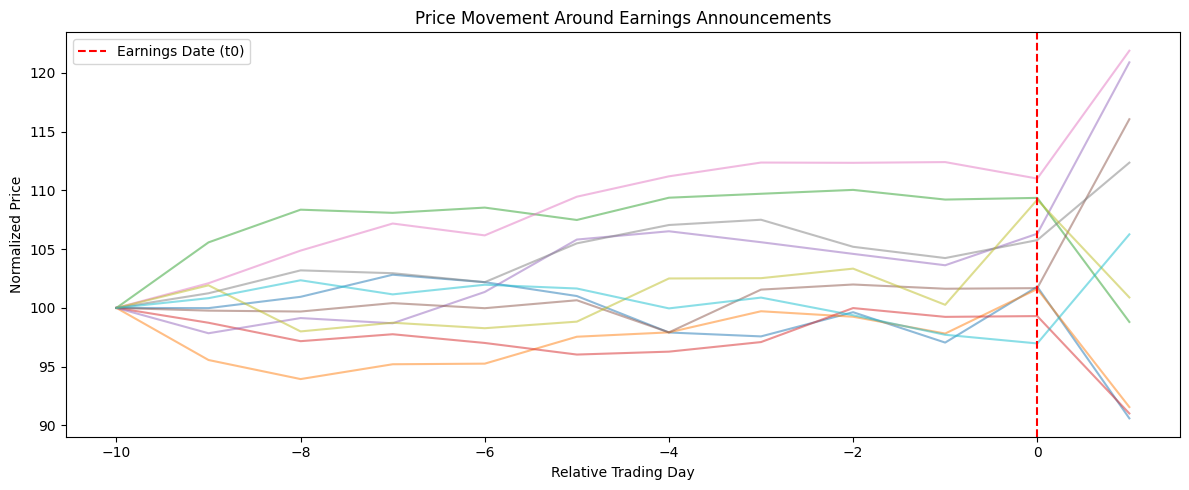

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Price Movement Across Event Window
close_cols = sorted(
    [c for c in modeling.columns if c.startswith("close_t")],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)
days = list(range(-10, 2))

fig, ax = plt.subplots(figsize=(12, 5))
for i in range(min(10, modeling.shape[0])):
    prices = modeling.select(close_cols).row(i)
    # normalize to 100 at t-10 for comparison
    base = prices[0]
    normalized = [p / base * 100 for p in prices]
    ax.plot(days, normalized, alpha=0.5)

ax.axvline(x=0, color="red", linestyle="--", label="Earnings Date (t0)")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Normalized Price")
ax.set_title("Price Movement Around Earnings Announcements")
ax.legend()
plt.tight_layout()
plt.show()

#### Volume Surge Around Earnings

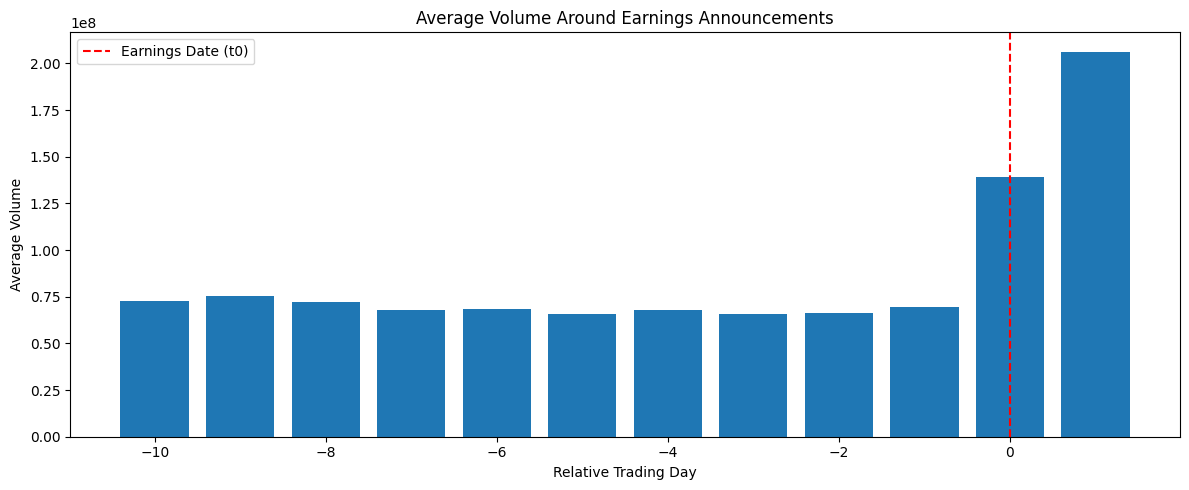

In [27]:
# Volume surge around the earnings date
volume_cols = sorted(
    [c for c in modeling.columns if c.startswith("volume_t")],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)

avg_vol = modeling.select(volume_cols).to_pandas().mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(days, avg_vol.values)
ax.axvline(x=0, color="red", linestyle="--", label="Earnings Date (t0)")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Average Volume")
ax.set_title("Average Volume Around Earnings Announcements")
ax.legend()
plt.tight_layout()
plt.show()

#### RSI Behavior Around Earnings

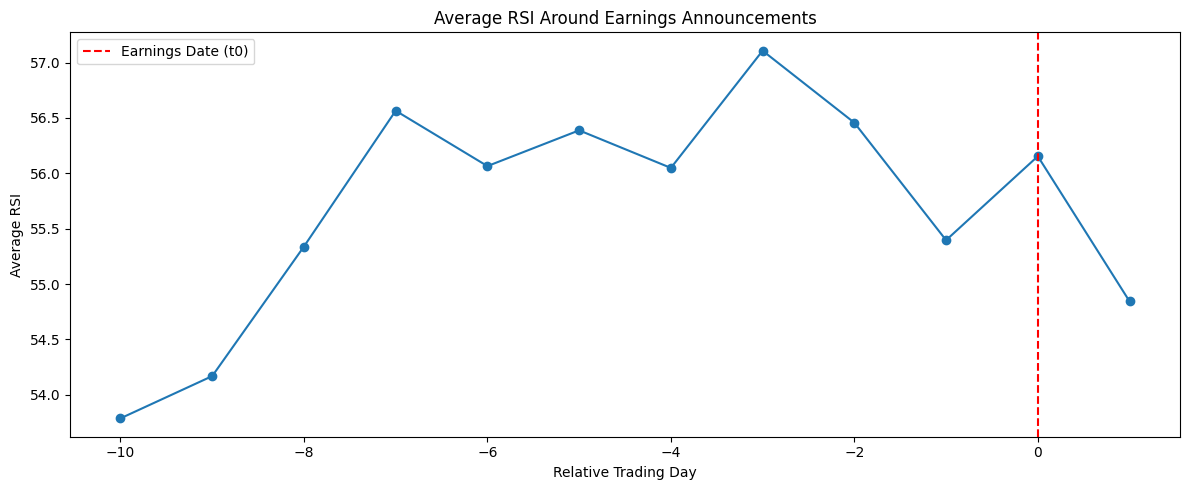

In [28]:
# RSI trend around earnings
rsi_cols = sorted(
    [c for c in modeling.columns if c.startswith("rsi_t")],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)

avg_rsi = modeling.select(rsi_cols).to_pandas().mean()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(days, avg_rsi.values, marker="o")
ax.axvline(x=0, color="red", linestyle="--", label="Earnings Date (t0)")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("Average RSI")
ax.set_title("Average RSI Around Earnings Announcements")
ax.legend()
plt.tight_layout()
plt.show()

#### EPS Surprise Distribution

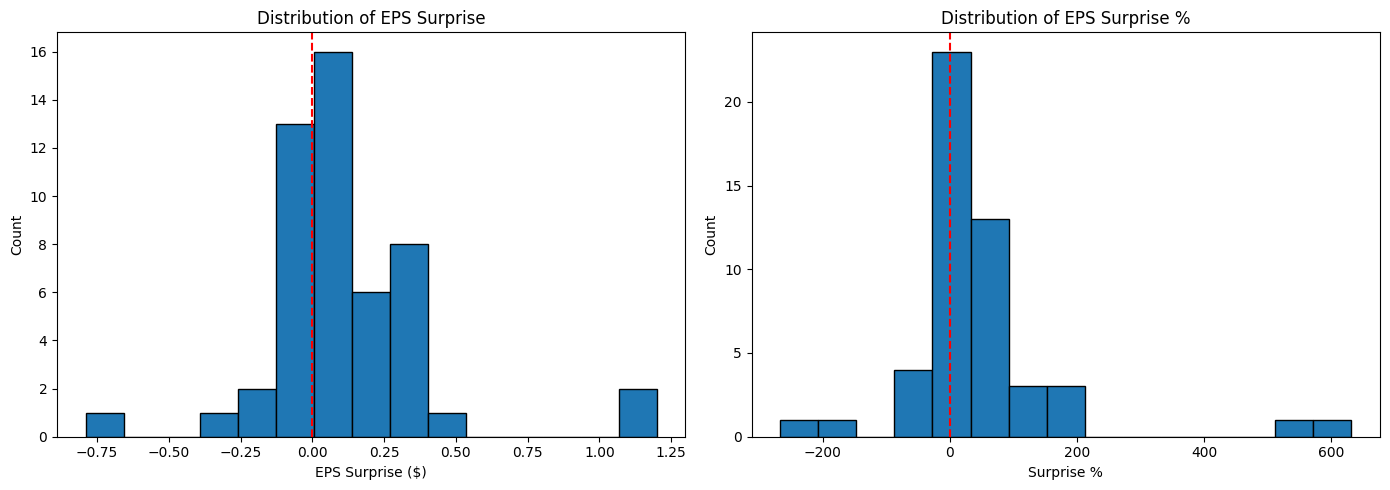

In [29]:
# EPS Surprise Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(modeling["surprise"].to_list(), bins=15, edgecolor="black")
axes[0].axvline(x=0, color="red", linestyle="--")
axes[0].set_xlabel("EPS Surprise ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of EPS Surprise")

axes[1].hist(modeling["surprisePercentage"].to_list(), bins=15, edgecolor="black")
axes[1].axvline(x=0, color="red", linestyle="--")
axes[1].set_xlabel("Surprise %")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of EPS Surprise %")

plt.tight_layout()
plt.show()

#### MACD Around Earnings

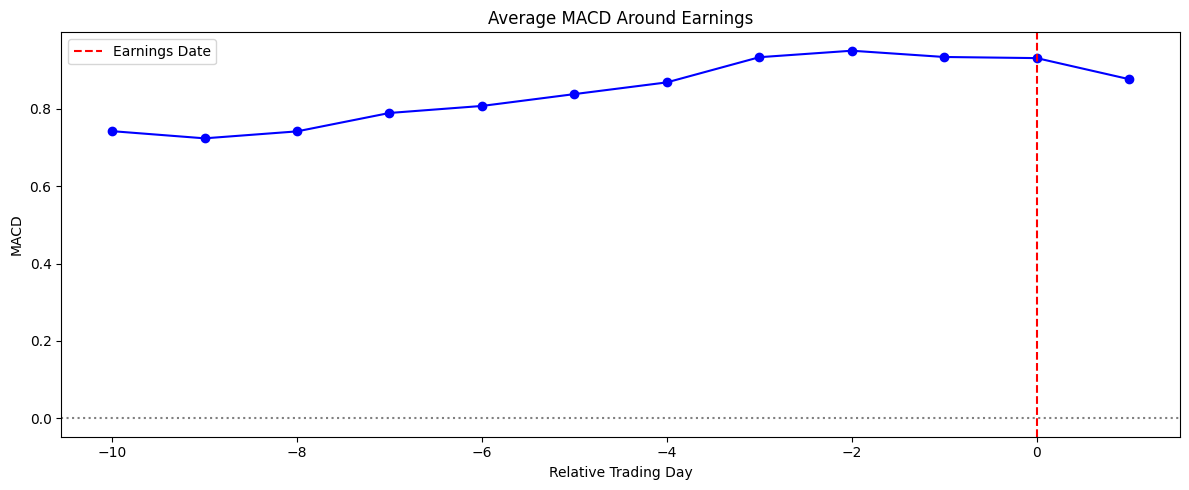

In [30]:
# MACD Around Earnings
macd_cols = sorted(
    [c for c in modeling.columns if c.startswith("macd_t") and "signal" not in c and "hist" not in c],
    key=lambda c: int(c.split("_t")[1].replace("+", ""))
)

avg_macd = modeling.select(macd_cols).to_pandas().mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(days, avg_macd.values, marker="o", color="blue")
ax.axhline(y=0, color="gray", linestyle=":")
ax.axvline(x=0, color="red", linestyle="--", label="Earnings Date")
ax.set_xlabel("Relative Trading Day")
ax.set_ylabel("MACD")
ax.set_title("Average MACD Around Earnings")
ax.legend()
plt.tight_layout()
plt.show()

###  Missing Values Audit

In [31]:
# Missing values check
print("Missing values check:")
print("=" *50)
null_counts = modeling.null_count()
total_cells = modeling.shape[0] * modeling.shape[1]
total_nulls = null_counts.sum_horizontal()[0]
print(f"Total cells: {total_cells}")
print(f"Total nulls: {total_nulls} ({100 * total_nulls / total_cells:.2f}%)")

# Nulls per column
cols_with_nulls = []
for c in modeling.columns:
    n = modeling[c].null_count()
    if n > 0:
        cols_with_nulls.append({"column": c, "nulls": n, "pct": round(100 * n / modeling.shape[0], 2)})

if cols_with_nulls:
    print(pl.DataFrame(cols_with_nulls).sort("nulls", descending=True))
else:
    print("No missing values found in any column")


Missing values check:
Total cells: 11850
Total nulls: 2 (0.02%)
shape: (2, 3)
┌────────────────┬───────┬─────┐
│ column         ┆ nulls ┆ pct │
│ ---            ┆ ---   ┆ --- │
│ str            ┆ i64   ┆ f64 │
╞════════════════╪═══════╪═════╡
│ eps_growth     ┆ 1     ┆ 2.0 │
│ surprise_trend ┆ 1     ┆ 2.0 │
└────────────────┴───────┴─────┘


#### Outlier Detection

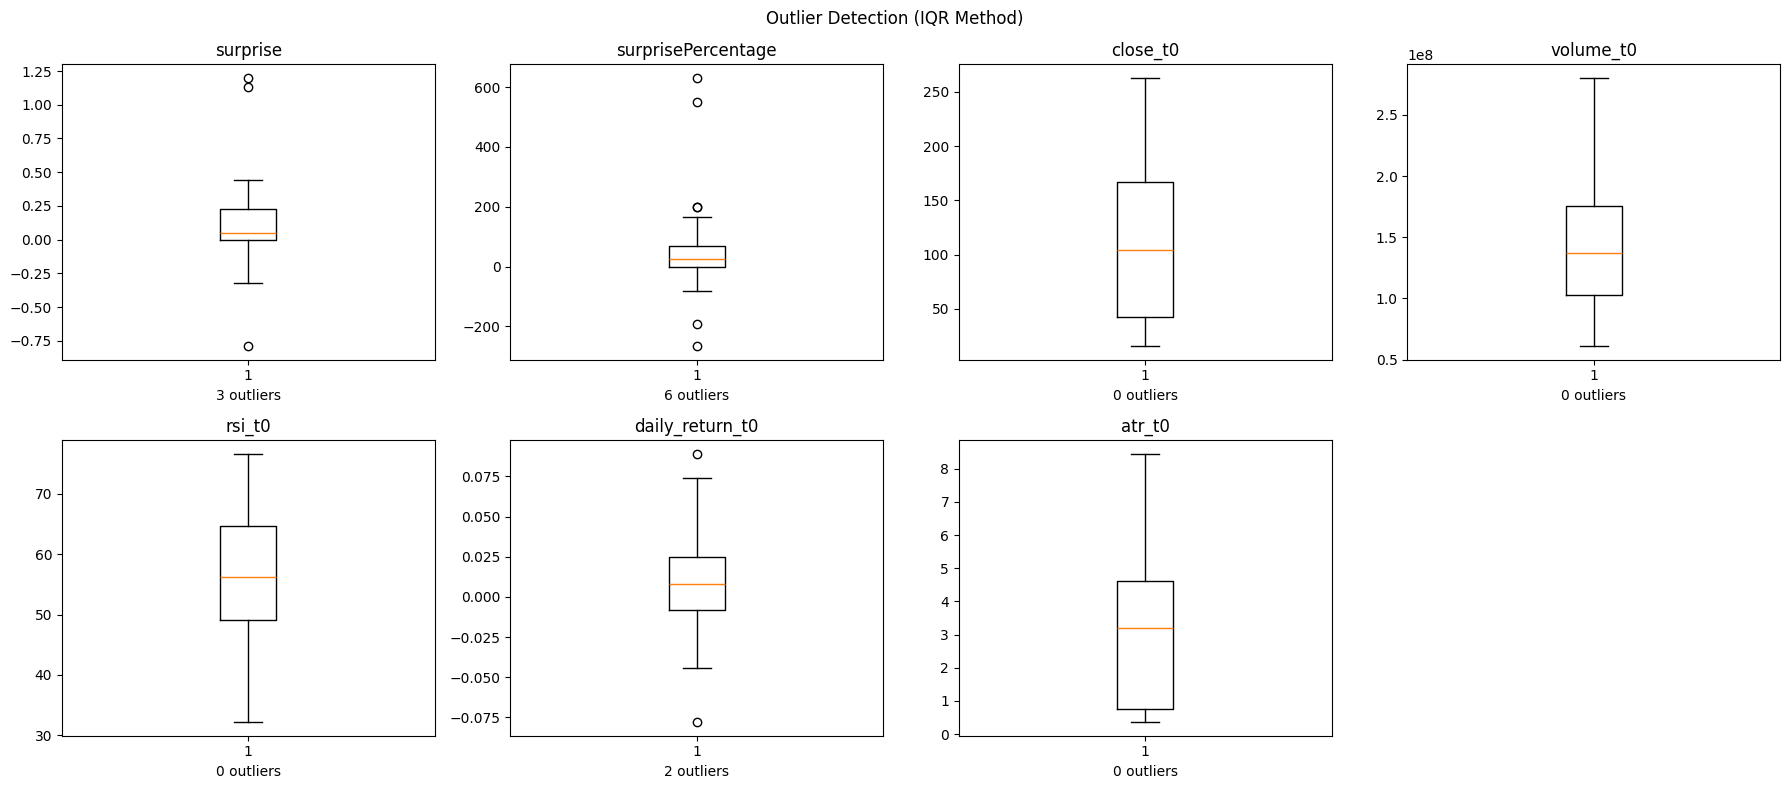

In [32]:
# Outlier detection using IQR method
import matplotlib.pyplot as plt

check_cols = ["surprise", "surprisePercentage", "close_t0", "volume_t0",
              "rsi_t0", "daily_return_t0", "atr_t0"]
check_cols = [c for c in check_cols if c in modeling.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    vals = modeling[col].to_list()
    axes[i].boxplot(vals)
    axes[i].set_title(col)

    # count outliers (IQR method)
    q1 = modeling[col].quantile(0.25)
    q3 = modeling[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = modeling.filter(
        (pl.col(col) < lower) | (pl.col(col) > upper)
    ).shape[0]
    axes[i].set_xlabel(f"{n_outliers} outliers")

# hide unused subplots
for j in range(len(check_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection (IQR Method)")
plt.tight_layout()
plt.show()

####  EPS Feature Analysis

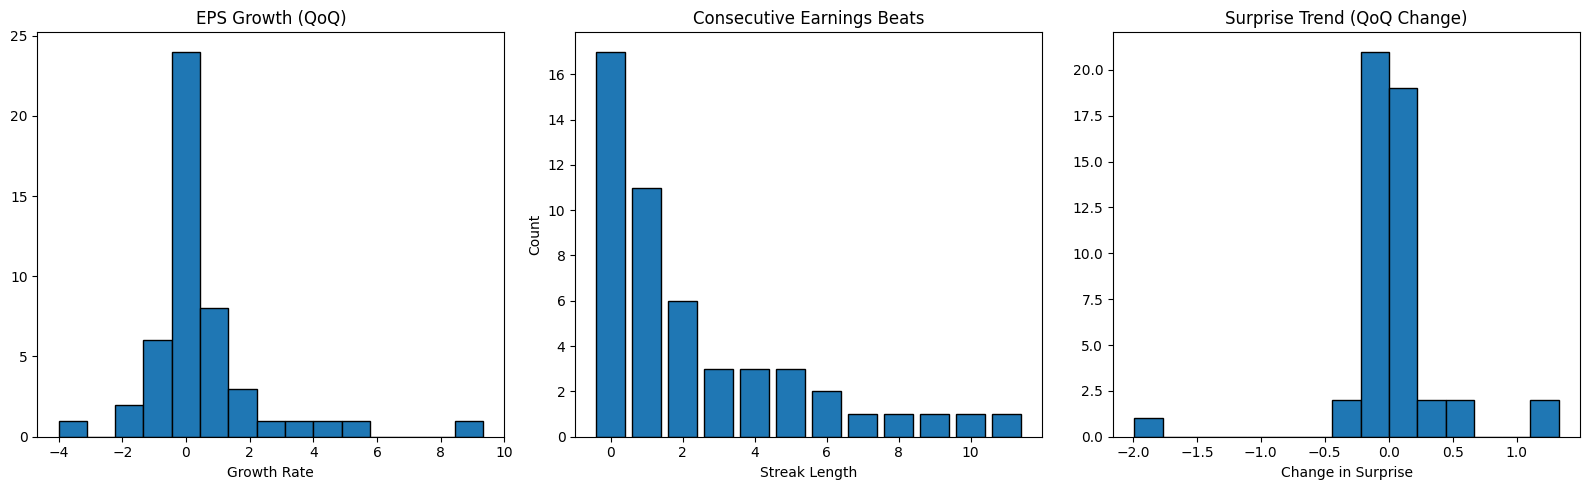

In [33]:
# EPS features analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# EPS growth distribution
axes[0].hist(modeling["eps_growth"].drop_nulls().to_list(), bins=15, edgecolor="black")
axes[0].set_title("EPS Growth (QoQ)")
axes[0].set_xlabel("Growth Rate")

# Consecutive beats
axes[1].bar(
    modeling["consecutive_beats"].value_counts().sort("consecutive_beats")["consecutive_beats"].to_list(),
    modeling["consecutive_beats"].value_counts().sort("consecutive_beats")["count"].to_list(),
    edgecolor="black"
)
axes[1].set_title("Consecutive Earnings Beats")
axes[1].set_xlabel("Streak Length")
axes[1].set_ylabel("Count")

# Surprise trend
axes[2].hist(modeling["surprise_trend"].drop_nulls().to_list(), bins=15, edgecolor="black")
axes[2].set_title("Surprise Trend (QoQ Change)")
axes[2].set_xlabel("Change in Surprise")

plt.tight_layout()
plt.show()

#### Transcript Length Analysis

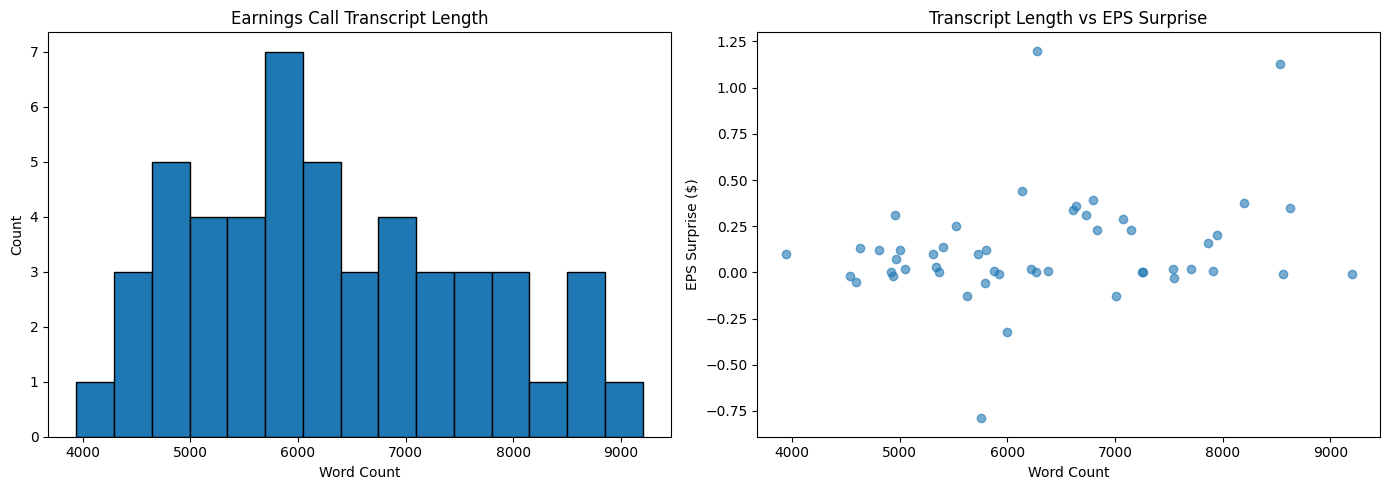

Avg transcript length: 6321 words
Shortest: 3942 words
Longest: 9199 words


In [34]:
# Transcript analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution
axes[0].hist(modeling["transcript_word_count"].to_list(), bins=15, edgecolor="black")
axes[0].set_title("Earnings Call Transcript Length")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Count")

# Word count vs surprise
axes[1].scatter(
    modeling["transcript_word_count"].to_list(),
    modeling["surprise"].to_list(),
    alpha=0.6
)
axes[1].set_title("Transcript Length vs EPS Surprise")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("EPS Surprise ($)")

plt.tight_layout()
plt.show()

print(f"Avg transcript length: {modeling['transcript_word_count'].mean():.0f} words")
print(f"Shortest: {modeling['transcript_word_count'].min()} words")
print(f"Longest: {modeling['transcript_word_count'].max()} words")

#### Temporal Trends

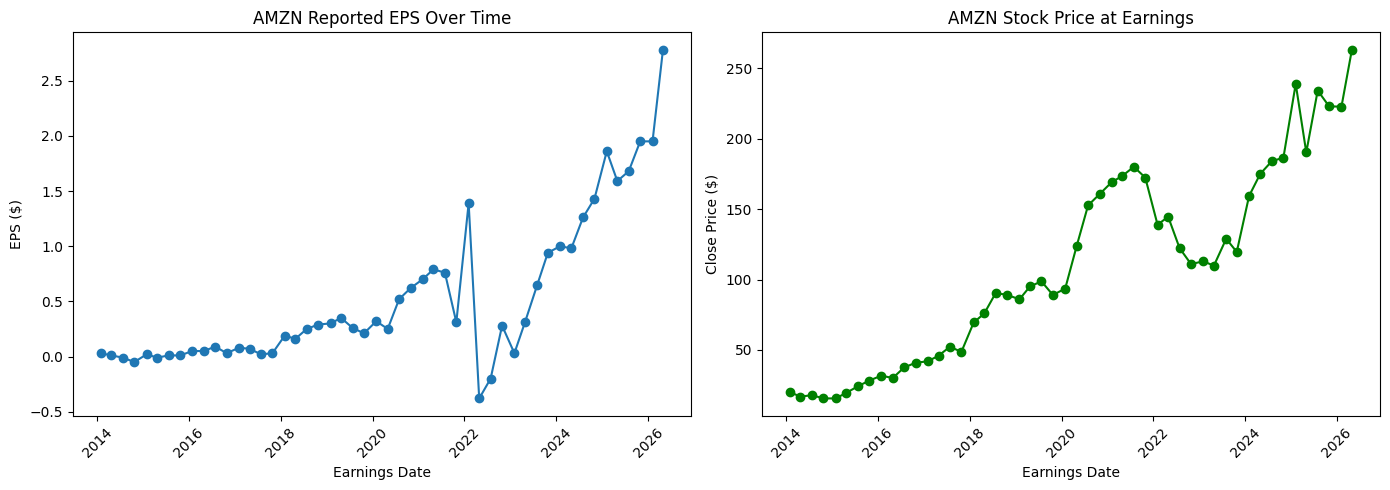

In [35]:
# How EPS and price evolved over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_model = modeling.sort("earnings_date")
dates = sorted_model["earnings_date"].to_list()

axes[0].plot(dates, sorted_model["reportedEPS"].to_list(), marker="o")
axes[0].set_title("AMZN Reported EPS Over Time")
axes[0].set_xlabel("Earnings Date")
axes[0].set_ylabel("EPS ($)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(dates, sorted_model["close_t0"].to_list(), marker="o", color="green")
axes[1].set_title("AMZN Stock Price at Earnings")
axes[1].set_xlabel("Earnings Date")
axes[1].set_ylabel("Close Price ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Post-Earnings Price Reaction

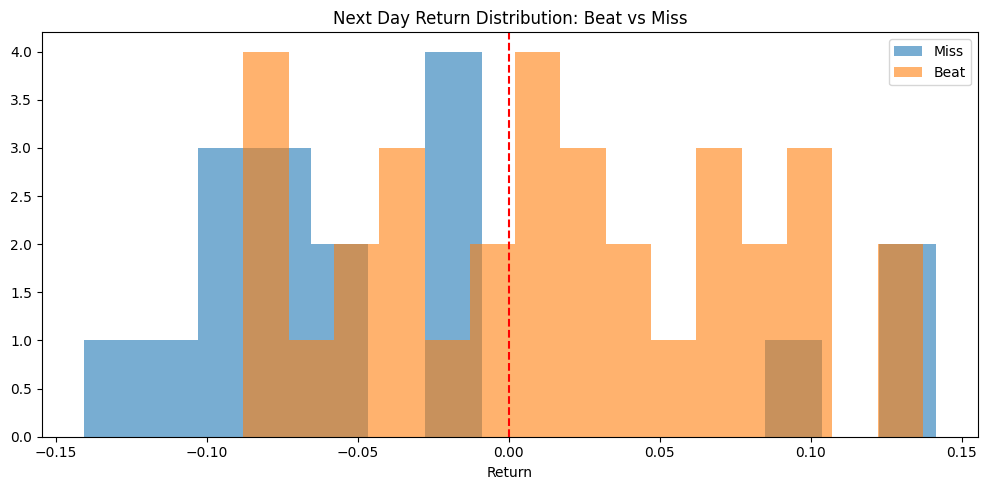

In [36]:
modeling_check = modeling.with_columns(
    ((pl.col("close_t+1") - pl.col("close_t0")) / pl.col("close_t0")).alias("next_day_return"),
    (pl.col("surprise").cast(pl.Float64) > 0).cast(pl.Int8).alias("beat")
)

fig, ax = plt.subplots(figsize=(10, 5))
for label, group in modeling_check.to_pandas().groupby("beat"):
    ax.hist(group["next_day_return"], bins=15, alpha=0.6, label="Beat" if label else "Miss")
ax.axvline(x=0, color="red", linestyle="--")
ax.set_title("Next Day Return Distribution: Beat vs Miss")
ax.set_xlabel("Return")
ax.legend()
plt.tight_layout()
plt.show()

#### Surprise % vs Price Reaction

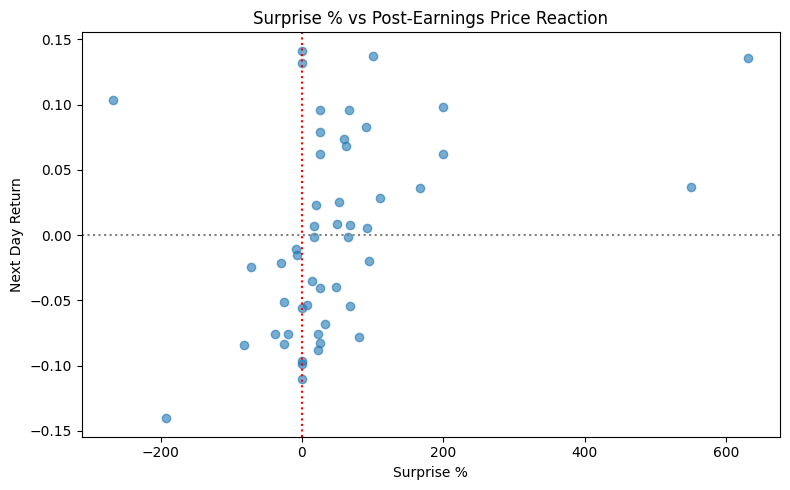

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    modeling_check["surprisePercentage"].to_list(),
    modeling_check["next_day_return"].to_list(),
    alpha=0.6
)
ax.axhline(y=0, color="gray", linestyle=":")
ax.axvline(x=0, color="red", linestyle=":")
ax.set_xlabel("Surprise %")
ax.set_ylabel("Next Day Return")
ax.set_title("Surprise % vs Post-Earnings Price Reaction")
plt.tight_layout()
plt.show()

#### Seasonal Patterns

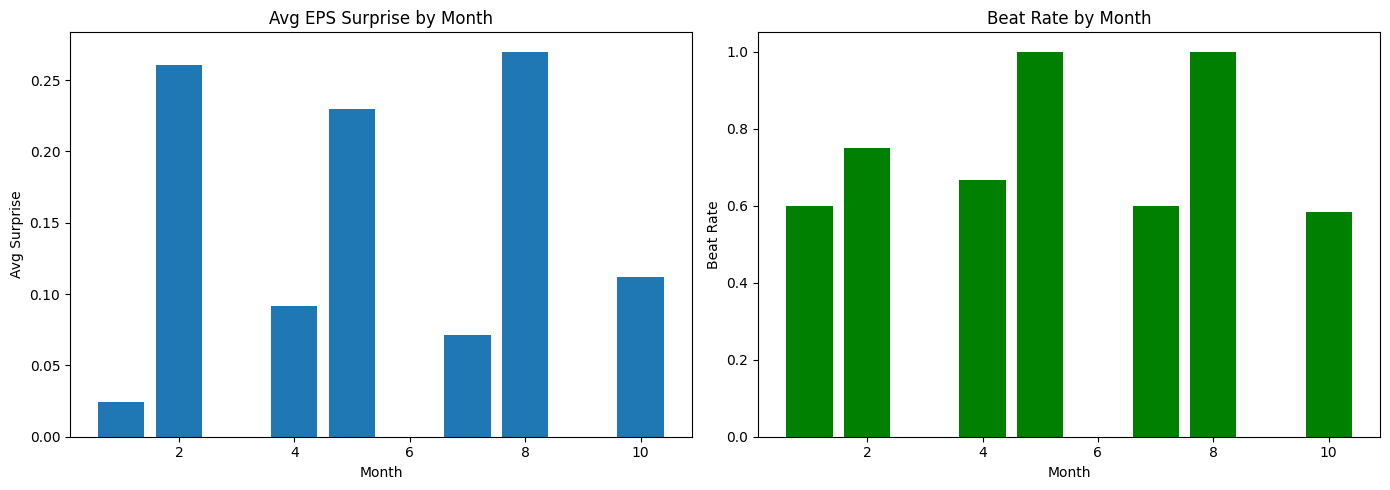

In [38]:
seasonal = modeling.with_columns(
    pl.col("earnings_date").dt.month().alias("month")
).group_by("month").agg(
    pl.col("surprise").cast(pl.Float64).mean().alias("avg_surprise"),
    (pl.col("surprise").cast(pl.Float64) > 0).cast(pl.Int8).mean().alias("beat_rate")
).sort("month")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(seasonal["month"].to_list(), seasonal["avg_surprise"].to_list())
axes[0].set_title("Avg EPS Surprise by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Surprise")

axes[1].bar(seasonal["month"].to_list(), seasonal["beat_rate"].to_list(), color="green")
axes[1].set_title("Beat Rate by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Beat Rate")
plt.tight_layout()
plt.show()

#### Dimensionality Reduction Analysis

In [39]:
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pivoted_cols = [c for c in modeling.columns
                if re.search(r"_t[+-]?\d+$", c)]

event_cols = [c for c in modeling.columns
              if c not in pivoted_cols]

print(f"Pivoted cols: {len(pivoted_cols)} | Event-level cols: {len(event_cols)}")

Pivoted cols: 216 | Event-level cols: 21


In [40]:
feature_groups = {}

for col in pivoted_cols:
    base = re.sub(r"_t[+-]?\d+$", "", col)
    feature_groups.setdefault(base, []).append(col)

print(f"\n Feature groups and temporal coorelation:")

for name, cols in feature_groups.items():
    if len(cols) > 1:
        corr_matrix = modeling.select(cols).to_pandas().corr()
        avg_corr = (corr_matrix.values.sum().sum() - len(cols)) / (len(cols) * (len(cols) - 1))
        print(f"{name}: {len(cols)} features | Avg pairwise corr: {avg_corr:.2f}")


 Feature groups and temporal coorelation:
atr: 12 features | Avg pairwise corr: 0.99
bb_lower: 12 features | Avg pairwise corr: 1.00
bb_middle: 12 features | Avg pairwise corr: 1.00
bb_upper: 12 features | Avg pairwise corr: 1.00
close: 12 features | Avg pairwise corr: 1.00
daily_return: 12 features | Avg pairwise corr: -0.03
gap: 12 features | Avg pairwise corr: -0.02
high: 12 features | Avg pairwise corr: 1.00
intraday_range: 12 features | Avg pairwise corr: 0.44
low: 12 features | Avg pairwise corr: 1.00
macd: 12 features | Avg pairwise corr: 0.92
macdhist: 12 features | Avg pairwise corr: 0.71
macdsignal: 12 features | Avg pairwise corr: 0.92
obv: 12 features | Avg pairwise corr: 1.00
open: 12 features | Avg pairwise corr: 1.00
rsi: 12 features | Avg pairwise corr: 0.73
volume_change: 12 features | Avg pairwise corr: -0.06
volume: 12 features | Avg pairwise corr: 0.59


#### PCA

Dropped 0 rows with nulls for PCA


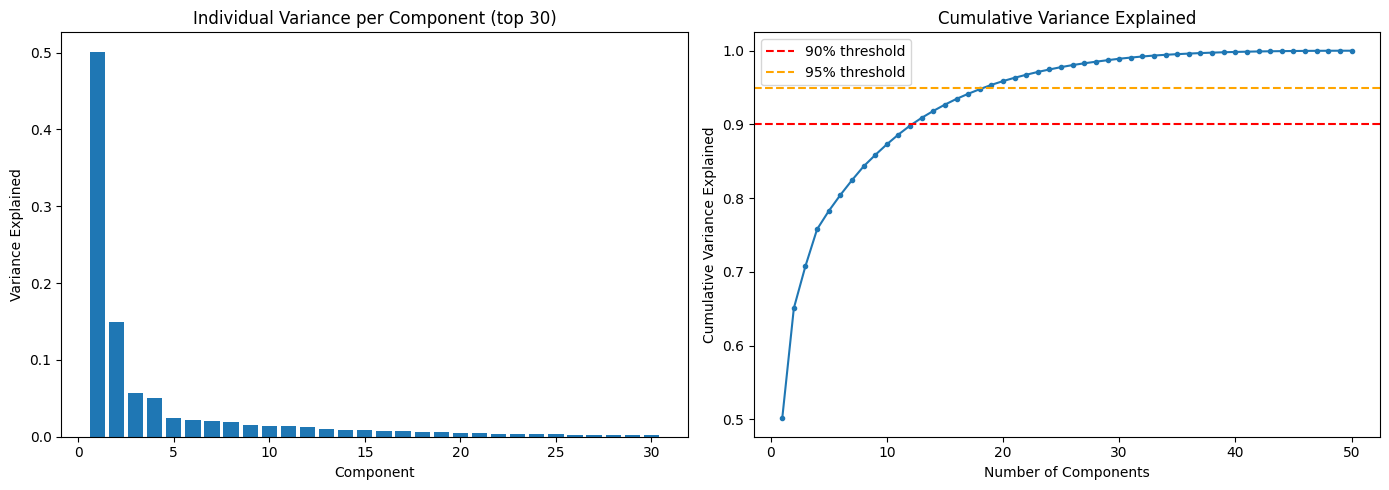


Components for 90% variance: 13 (from 216)
Components for 95% variance: 19 (from 216)
Reduction: 216 -> 13 columns (94% reduction)


In [41]:

pca_data = modeling.select(pivoted_cols).to_pandas()

# drop rows with any nulls for PCA
rows_before = len(pca_data)
pca_data = pca_data.dropna()
print(f"Dropped {rows_before - len(pca_data)} rows with nulls for PCA")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scale features
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

# fit PCA
pca_full = PCA()
pca_full.fit(pca_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

#plot cumulative variance
axes[0].bar(range(1, min(31, len(pca_full.explained_variance_ratio_) + 1)),
            pca_full.explained_variance_ratio_[:30])
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance Explained")
axes[0].set_title("Individual Variance per Component (top 30)")

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker=".")
axes[1].axhline(y=0.90, color="red", linestyle="--", label="90% threshold")
axes[1].axhline(y=0.95, color="orange", linestyle="--", label="95% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()

plt.tight_layout()
plt.show()

n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents for 90% variance: {n_90} (from {len(pivoted_cols)})")
print(f"Components for 95% variance: {n_95} (from {len(pivoted_cols)})")
print(f"Reduction: {len(pivoted_cols)} -> {n_90} columns ({100*(1 - n_90/len(pivoted_cols)):.0f}% reduction)")


#### Correlation-Based Feature Selection

In [42]:
# Correlation-based selection

corr_matrix = pca_data.corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

print(f"Correlation-based selection (threshold=0.95):")
print(f"  Highly correlated columns: {len(high_corr_cols)}")
print(f"  Remaining after dropping:  {len(pivoted_cols) - len(high_corr_cols)}")

print(f"\nComparison:")
print(f"  Original features:        {len(pivoted_cols)}")
print(f"  After PCA (90% var):      {n_90}")
print(f"  After corr selection:     {len(pivoted_cols) - len(high_corr_cols)}")

Correlation-based selection (threshold=0.95):
  Highly correlated columns: 138
  Remaining after dropping:  78

Comparison:
  Original features:        216
  After PCA (90% var):      13
  After corr selection:     78
